#  Pengaruh Tidur, Stres, dan Aktivitas Fisik pada Random Forest-SHAP untuk Prediksi Stroke
**Dataset:** NHANES 2015-2016  
**Metode:** Decision Tree, Random Forest, XGBoost + SHAP  
**Tugas Besar Kecerdasan Buatan - 2026**

---
## Alur Notebook
1. Install & Import Library
2. Download & Load Dataset NHANES
3. Merge Semua File by SEQN
4. Seleksi Kolom & Preprocessing
5. Desain Eksperimen (5 skenario)
6. Training & Evaluasi Model
7. Visualisasi Hasil
8. Analisis SHAP

##  1. Install & Import Library

In [1]:
# Install library tambahan yang tidak ada di Colab by default
!pip install shap imbalanced-learn xgboost -q

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, RocCurveDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

# Styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#2C3E93', '#F5A623', '#10B981', '#E74C3C', '#8B5CF6']

print('Semua library berhasil diimport!')


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Semua library berhasil diimport!


##  2. Download & Load Dataset NHANES 2015-2016

In [2]:
if not os.path.exists('NHANES-Stroke-Dataset'):
    os.system('git clone https://github.com/Adityamulyaf/NHANES-Stroke-Dataset.git')

# Tentukan path dataset
if os.path.exists('content/'):
    DATA_PATH = 'content/'
elif os.path.exists('NHANES-Stroke-Dataset/content/'):
    DATA_PATH = 'NHANES-Stroke-Dataset/content/'
else:
    DATA_PATH = '/content/NHANES-Stroke-Dataset/content/'

# Cek isi folder
print("File tersedia:")
for f in os.listdir(DATA_PATH):
    print(f" - {f}")

File tersedia:
 - BMX_I.xpt
 - BPQ_I.xpt
 - BPX_I.xpt
 - DEMO_I.xpt
 - DIQ_I.xpt
 - DPQ_I.xpt
 - MCQ_I.xpt
 - PAQ_I.xpt
 - SLQ_I.xpt
 - SMQ_I.xpt


In [3]:
import pandas as pd
import numpy as np

dfs = {}
files = {
    'demo': 'DEMO_I.xpt',
    'mcq':  'MCQ_I.xpt',
    'bpq':  'BPQ_I.xpt',
    'diq':  'DIQ_I.xpt',
    'bmx':  'BMX_I.xpt',
    'bpx':  'BPX_I.xpt',
    'smq':  'SMQ_I.xpt',
    'slq':  'SLQ_I.xpt',
    'dpq':  'DPQ_I.xpt',
    'paq':  'PAQ_I.xpt',
}

for name, filename in files.items():
    path = os.path.join(DATA_PATH, filename)
    print(f'Loading {filename}...', end=' ')
    try:
        dfs[name] = pd.read_sas(path, format='xport', encoding='utf-8')
        print(f'Berhasil: {dfs[name].shape[0]:,} baris, {dfs[name].shape[1]} kolom')
    except Exception as e:
        print(f'Gagal: {e}')

print('\nSemua file berhasil diload!')

Loading DEMO_I.xpt... Berhasil: 9,971 baris, 47 kolom
Loading MCQ_I.xpt... Berhasil: 9,575 baris, 90 kolom
Loading BPQ_I.xpt... Berhasil: 6,327 baris, 11 kolom
Loading DIQ_I.xpt... 

Berhasil: 9,575 baris, 54 kolom
Loading BMX_I.xpt... 

Berhasil: 9,544 baris, 26 kolom
Loading BPX_I.xpt... Berhasil: 9,544 baris, 21 kolom
Loading SMQ_I.xpt... Berhasil: 7,001 baris, 42 kolom
Loading SLQ_I.xpt... Berhasil: 6,327 baris, 8 kolom
Loading DPQ_I.xpt... Berhasil: 5,735 baris, 11 kolom
Loading PAQ_I.xpt... Berhasil: 9,255 baris, 94 kolom

Semua file berhasil diload!


##  3. Merge Semua File by SEQN

In [4]:
# Pilih kolom relevan dari setiap file
# Demografi
demo_cols = ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR']
demo_clean = dfs['demo'][demo_cols].copy()

# Target stroke
mcq_cols = ['SEQN', 'MCQ160F', 'MCQ160B', 'MCQ160C', 'MCQ160E']
mcq_clean = dfs['mcq'][mcq_cols].copy()

# Hipertensi dan Diabetes
bpq_cols = ['SEQN', 'BPQ020']
bpq_clean = dfs['bpq'][bpq_cols].copy()

diq_cols = ['SEQN', 'DIQ010']
diq_clean = dfs['diq'][diq_cols].copy()

# Pemeriksaan Fisik
bmx_cols = ['SEQN', 'BMXBMI', 'BMXWAIST']
bmx_clean = dfs['bmx'][bmx_cols].copy()

bpx_cols = ['SEQN', 'BPXSY1', 'BPXDI1']
bpx_clean = dfs['bpx'][bpx_cols].copy()

# Merokok
smq_cols = ['SEQN', 'SMQ020', 'SMQ040']
smq_clean = dfs['smq'][smq_cols].copy()

# Tidur (5 Fitur)
slq_cols = ['SEQN', 'SLD012', 'SLQ030', 'SLQ040', 'SLQ050', 'SLQ120']
slq_clean = dfs['slq'][slq_cols].copy()

# Stres (5 Fitur)
dpq_cols = ['SEQN'] + [f'DPQ0{i}0' for i in range(1, 10)]
dpq_clean = dfs['dpq'][dpq_cols].copy()

# Pembersihan nilai kuesioner stres (hanya nilai 0-3 yang valid, selebihnya NaN)
phq_items = [f'DPQ0{i}0' for i in range(1, 10)]
for col in phq_items:
    dpq_clean[col] = dpq_clean[col].apply(lambda x: x if x <= 3.0 else np.nan)

# Membuat stress_score (skor total depresi/stres)
dpq_clean['stress_score'] = dpq_clean[phq_items].apply(
    lambda row: row.sum() if row.notna().sum() >= 7 else np.nan, axis=1
)

# Ganti nama 4 fitur kuesioner terpilih agar lebih deskriptif
dpq_rename = {
    'DPQ010': 'stress_anhedonia',
    'DPQ020': 'stress_depressed',
    'DPQ040': 'stress_fatigue',
    'DPQ060': 'stress_self_esteem'
}
dpq_clean = dpq_clean.rename(columns=dpq_rename)
stress_cols = ['SEQN', 'stress_score', 'stress_anhedonia', 'stress_depressed', 'stress_fatigue', 'stress_self_esteem']
dpq_clean = dpq_clean[stress_cols]

# Fitur Aktivitas Fisik (5 Fitur)
paq_cols = ['SEQN', 'PAQ605', 'PAD615', 'PAQ650', 'PAQ665', 'PAD680']
paq_clean = dfs['paq'][paq_cols].copy()

# Menggabungkan semua dataset berdasarkan nomor responden (SEQN)
df = demo_clean
for other in [mcq_clean, bpq_clean, diq_clean, bmx_clean,
              bpx_clean, smq_clean, slq_clean, dpq_clean, paq_clean]:
    df = df.merge(other, on='SEQN', how='left')

print(f"Total baris setelah penggabungan: {df.shape[0]}")
print(f"Total kolom setelah penggabungan: {df.shape[1]}")
df.head()

Total baris setelah penggabungan: 9971
Total kolom setelah penggabungan: 33


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,INDFMPIR,MCQ160F,MCQ160B,MCQ160C,MCQ160E,...,stress_score,stress_anhedonia,stress_depressed,stress_fatigue,stress_self_esteem,PAQ605,PAD615,PAQ650,PAQ665,PAD680
0,83732.0,62.0,1.0,3.0,5.0,4.39,2.0,2.0,2.0,2.0,...,1.0,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,2.0,NaN,2.0,1.0,480.0
1,83733.0,53.0,1.0,3.0,3.0,1.32,2.0,2.0,2.0,2.0,...,2.0,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,2.0,NaN,2.0,2.0,300.0
2,83734.0,78.0,1.0,3.0,3.0,1.51,2.0,2.0,2.0,1.0,...,1.0,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,2.0,NaN,2.0,2.0,480.0
3,83735.0,56.0,2.0,3.0,5.0,5.00,2.0,2.0,2.0,2.0,...,13.0,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,2.0,NaN,2.0,2.0,480.0
4,83736.0,42.0,2.0,4.0,4.0,1.23,2.0,2.0,2.0,2.0,...,8.0,1.000000e+00,1.000000e+00,1.000000e+00,5.397605e-79,2.0,NaN,2.0,2.0,540.0


##  4. Preprocessing

In [5]:
# Pembuatan variabel target (Stroke)
df['stroke'] = df['MCQ160F'].map({1.0: 1, 2.0: 0})

# Hapus baris yang tidak memiliki label target (stroke)
df = df[df['stroke'].notna()].copy()
print("Distribusi awal variabel stroke:")
print(df['stroke'].value_counts())
print(f"Rasio stroke positif: {df['stroke'].mean():.2%}")

# Filter hanya responden berusia dewasa (18 tahun ke atas)
df = df[df['RIDAGEYR'] >= 18].copy()
print(f"Jumlah data setelah filter usia dewasa: {len(df)} baris")

Distribusi awal variabel stroke:
stroke
0.0    5505
1.0     209
Name: count, dtype: int64
Rasio stroke positif: 3.66%
Jumlah data setelah filter usia dewasa: 5714 baris


In [6]:
# Encoding variabel kategorik dan biner ke format 1/0
binary_cols = {
    'BPQ020': 'hypertension',    # 1=Ya, 2=Tidak
    'DIQ010': 'diabetes',         # 1=Ya, 2=Tidak (nilai 3=Borderline dikelompokkan ke 1)
    'MCQ160B': 'heart_failure',
    'MCQ160C': 'coronary_disease',
    'MCQ160E': 'heart_attack',
    'SMQ020': 'ever_smoked',
    'SLQ050': 'sleep_problem_doctor',
    'PAQ605': 'vigorous_work',
    'PAQ650': 'vigorous_leisure',
    'PAQ665': 'moderate_leisure',
}

for old, new in binary_cols.items():
    if old in df.columns:
        df[new] = df[old].map({1.0: 1, 2.0: 0, 3.0: 1})

# Mengubah nama kolom agar lebih deskriptif
rename_map = {
    'RIDAGEYR': 'age',
    'RIAGENDR': 'gender',          # 1=Laki-laki, 2=Perempuan
    'RIDRETH3': 'race',
    'DMDEDUC2': 'education',
    'INDFMPIR': 'income_ratio',
    'BMXBMI':   'bmi',
    'BMXWAIST': 'waist_circ',
    'BPXSY1':   'systolic_bp',
    'BPXDI1':   'diastolic_bp',
    'SMQ040':   'current_smoker',  # 1=setiap hari, 2=kadang-kadang, 3=tidak sama sekali
    'SLD012':   'sleep_hours',
    'SLQ030':   'snoring_freq',
    'SLQ040':   'sleep_apnea',
    'SLQ120':   'daytime_sleepy',
    'PAD615':   'vigorous_work_min',
    'PAD680':   'sedentary_min',
}

df = df.rename(columns=rename_map)

# Konversi gender: 1=Laki-laki -> 1, 2=Perempuan -> 0
df['gender'] = df['gender'].map({1.0: 1, 2.0: 0})

print("Encoding selesai")

Encoding selesai


In [7]:
# Fitur Klinis Dasar (Baseline)
CLINICAL = [
    'age', 'gender', 'race', 'education', 'income_ratio',
    'bmi', 'waist_circ', 'systolic_bp', 'diastolic_bp',
    'hypertension', 'diabetes', 'heart_failure',
    'coronary_disease', 'heart_attack',
    'ever_smoked', 'current_smoker'
]

# Fitur Tidur (5 Fitur)
SLEEP = [
    'sleep_hours', 'snoring_freq', 'sleep_apnea',
    'sleep_problem_doctor', 'daytime_sleepy'
]

# Fitur Stres (5 Fitur)
STRESS = [
    'stress_score', 'stress_anhedonia', 'stress_depressed',
    'stress_fatigue', 'stress_self_esteem'
]

# Fitur Aktivitas Fisik (5 Fitur)
PHYSICAL = [
    'vigorous_work', 'vigorous_work_min', 'vigorous_leisure',
    'moderate_leisure', 'sedentary_min'
]

TARGET = 'stroke'

# Memilih kolom yang digunakan dalam pemodelan
ALL_COLS = CLINICAL + SLEEP + STRESS + PHYSICAL + [TARGET]
df_model = df[ALL_COLS].copy()

print(f"Total fitur yang digunakan: {len(ALL_COLS) - 1}")
print(f" - Fitur Klinis: {len(CLINICAL)}")
print(f" - Fitur Tidur: {len(SLEEP)}")
print(f" - Fitur Stres: {len(STRESS)}")
print(f" - Fitur Aktivitas Fisik: {len(PHYSICAL)}")

Total fitur yang digunakan: 31
 - Fitur Klinis: 16
 - Fitur Tidur: 5
 - Fitur Stres: 5
 - Fitur Aktivitas Fisik: 5


In [8]:
print("Missing values sebelum:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

# Hapus baris yang missing di fitur klinis utama
core_cols = ['age', 'bmi', 'systolic_bp', 'hypertension', 'diabetes', TARGET]
df_model = df_model.dropna(subset=core_cols)

# Imputasi nilai median untuk kolom numerik sisanya
from sklearn.impute import SimpleImputer

num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

imp = SimpleImputer(strategy='median')
df_model[num_cols] = imp.fit_transform(df_model[num_cols])

print(f"Baris setelah handling missing: {len(df_model):,}")
print(f"Distribusi stroke: {df_model[TARGET].value_counts().to_dict()}")

Missing values sebelum:
income_ratio             635
bmi                      312
waist_circ               600
systolic_bp              566
diastolic_bp             566
hypertension               6
diabetes                   3
heart_failure             11
coronary_disease          25
heart_attack               8
ever_smoked               10
current_smoker          3330
sleep_hours               32
sleep_problem_doctor       4
stress_score             806
stress_anhedonia         813
stress_depressed         803
stress_fatigue           803
stress_self_esteem       805
vigorous_work              2
vigorous_work_min       4549
vigorous_leisure           1
moderate_leisure           4
sedentary_min             11
dtype: int64
Baris setelah handling missing: 5,090
Distribusi stroke: {0.0: 4913, 1.0: 177}


##  5. Desain Eksperimen - 5 Skenario

In [9]:
SCENARIOS = {
    'A: Klinis saja':              CLINICAL,
    'B: Klinis + Tidur':           CLINICAL + SLEEP,
    'C: Klinis + Stres':           CLINICAL + STRESS,
    'D: Klinis + Aktivitas':       CLINICAL + PHYSICAL,
    'E: Klinis + Semua Gaya Hidup': CLINICAL + SLEEP + STRESS + PHYSICAL,
}

MODELS = {
    'Decision Tree':  DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest':  RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                             class_weight='balanced', n_jobs=-1),
    'XGBoost':        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                    random_state=42, eval_metric='logloss',
                                    scale_pos_weight=10, verbosity=0),
}

print('Skenario dan model sudah didefinisikan')
print('Skenario:')
for name, feats in SCENARIOS.items():
    print(f'  {name}: {len(feats)} fitur')

Skenario dan model sudah didefinisikan
Skenario:
  A: Klinis saja: 16 fitur
  B: Klinis + Tidur: 21 fitur
  C: Klinis + Stres: 21 fitur
  D: Klinis + Aktivitas: 21 fitur
  E: Klinis + Semua Gaya Hidup: 31 fitur


##  6. Training & Evaluasi Model

In [10]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Train model dengan SMOTE lalu evaluasi."""
    # SMOTE hanya pada training set
    sm = SMOTE(random_state=42, k_neighbors=3)
    X_res, y_res = sm.fit_resample(X_train, y_train)

    # Scaling
    scaler = StandardScaler()
    X_res_sc  = scaler.fit_transform(X_res)
    X_test_sc = scaler.transform(X_test)

    # Train
    model.fit(X_res_sc, y_res)

    # Predict
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    return {
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(roc_auc_score(y_test, y_proba), 4) if np.all(y_pred == 0) else round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred,        zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4),
    }, model, scaler


# --- RUN SEMUA EKSPERIMEN ---------------------------------
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET].astype(int)

# Split sekali, pakai untuk semua skenario (reproducible)
X_tr_full, X_te_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

all_results = []
shap_best_model = {} # Store the best model for SHAP (Random Forest, Scenario E)
scenario_E_trained_models = {} # Store all trained models for Scenario E for ROC plot
model_names = list(MODELS.keys())

for scenario_name, feat_cols in SCENARIOS.items():
    # Filter kolom yang tersedia
    available = [c for c in feat_cols if c in X.columns]
    X_tr = X_tr_full[available]
    X_te = X_te_full[available]

    for model_name, model in MODELS.items():
        import copy
        m = copy.deepcopy(model)
        metrics, trained_m, scaler = evaluate_model(m, X_tr, X_te, y_train, y_test)

        all_results.append({
            'Skenario': scenario_name,
            'Model': model_name,
            **metrics
        })

        if scenario_name == 'E: Klinis + Semua Gaya Hidup':
            scenario_E_trained_models[model_name] = {
                'model': trained_m,
                'scaler': scaler,
                'features': available,
                'X_test': X_te,
                'y_test': y_test,
                'metrics': metrics
            }
            if model_name == 'Random Forest':
                shap_best_model['best'] = scenario_E_trained_models[model_name] # Assign the full model data

        print(f'{scenario_name} | {model_name} | AUC: {metrics["AUC-ROC"]}')

results_df = pd.DataFrame(all_results)
best = shap_best_model['best'] # This makes `best` available for the SHAP section.
trained_models = shap_best_model # Define trained_models as alias to prevent NameError

print('\nSemua eksperimen selesai!')

A: Klinis saja | Decision Tree | AUC: 0.6521


A: Klinis saja | Random Forest | AUC: 0.7482


A: Klinis saja | XGBoost | AUC: 0.7031
B: Klinis + Tidur | Decision Tree | AUC: 0.7082


B: Klinis + Tidur | Random Forest | AUC: 0.7849


B: Klinis + Tidur | XGBoost | AUC: 0.7194
C: Klinis + Stres | Decision Tree | AUC: 0.6895


...

C: Klinis + Stres | XGBoost | AUC: 0.7456
D: Klinis + Aktivitas | Decision Tree | AUC: 0.7578


D: Klinis + Aktivitas | Random Forest | AUC: 0.7898


D: Klinis + Aktivitas | XGBoost | AUC: 0.694
E: Klinis + Semua Gaya Hidup | Decision Tree | AUC: 0.726


E: Klinis + Semua Gaya Hidup | Random Forest | AUC: 0.7815


E: Klinis + Semua Gaya Hidup | XGBoost | AUC: 0.742

Semua eksperimen selesai!


##  7. Visualisasi Hasil

In [11]:
# --- TABEL HASIL LENGKAP ---------------------------------
print('=== TABEL HASIL SEMUA EKSPERIMEN ===')
display(results_df.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1','AUC-ROC'],
                   color='#d4edda')
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}',
             'Recall':'{:.4f}','F1':'{:.4f}','AUC-ROC':'{:.4f}'})
    .set_properties(**{'font-size': '11pt'})
)

=== TABEL HASIL SEMUA EKSPERIMEN ===


,Skenario,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,A: Klinis saja,Decision Tree,0.9489,0.0526,0.0286,0.0370,0.6521
1,A: Klinis saja,Random Forest,0.9470,0.0476,0.0286,0.0357,0.7482
2,A: Klinis saja,XGBoost,0.9293,0.0488,0.0571,0.0526,0.7031
3,B: Klinis + Tidur,Decision Tree,0.9391,0.1143,0.1143,0.1143,0.7082
4,B: Klinis + Tidur,Random Forest,0.9440,0.0417,0.0286,0.0339,0.7849
5,B: Klinis + Tidur,XGBoost,0.9322,0.0952,0.1143,0.1039,0.7194
6,C: Klinis + Stres,Decision Tree,0.9656,0.5000,0.0286,0.0541,0.6895
7,C: Klinis + Stres,Random Forest,0.9440,0.0417,0.0286,0.0339,0.7510
8,C: Klinis + Stres,XGBoost,0.9420,0.0714,0.0571,0.0635,0.7456
9,D: Klinis + Aktivitas,Decision Tree,0.8792,0.0849,0.2571,0.1277,0.7578


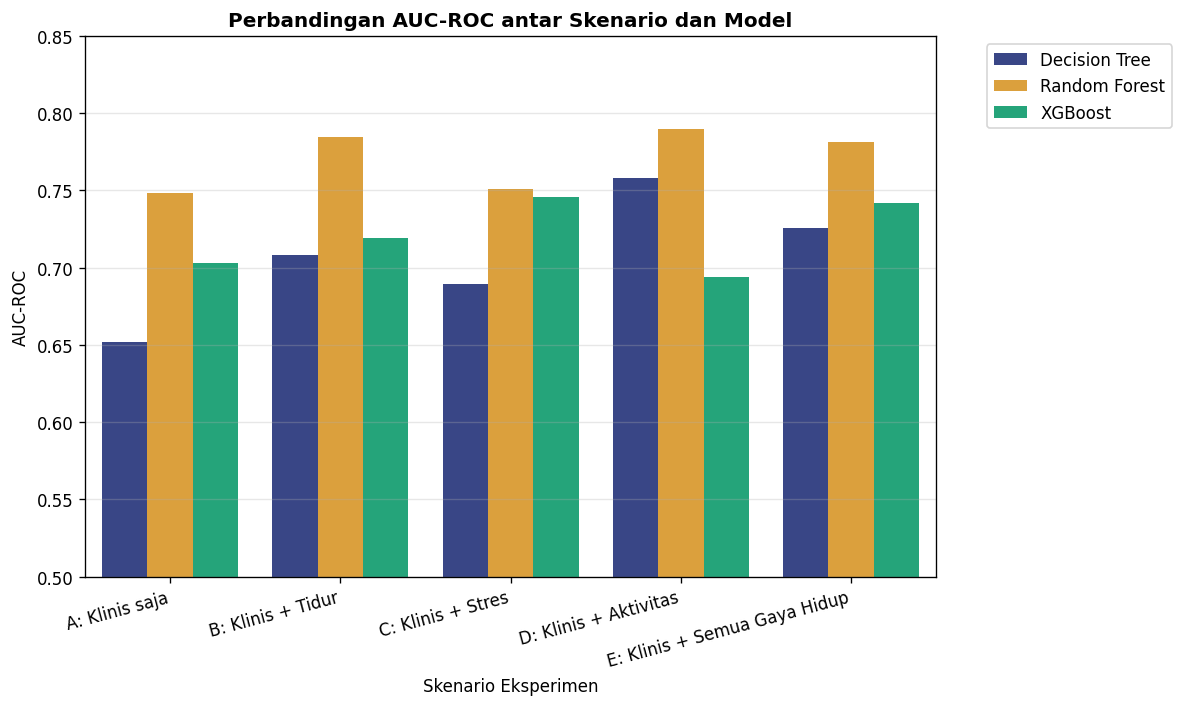

Chart tersimpan sebagai auc_comparison.png


In [12]:
# --- CHART: AUC-ROC PER SKENARIO & MODEL -----------------
plt.figure(figsize=(10, 6))
sns.barplot(x='Skenario', y='AUC-ROC', hue='Model', data=results_df, palette=COLORS[:3])
plt.title('Perbandingan AUC-ROC antar Skenario dan Model', fontsize=12, fontweight='bold')
plt.xlabel('Skenario Eksperimen', fontsize=10)
plt.ylabel('AUC-ROC', fontsize=10)
plt.ylim(0.5, 0.85)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart tersimpan sebagai auc_comparison.png')

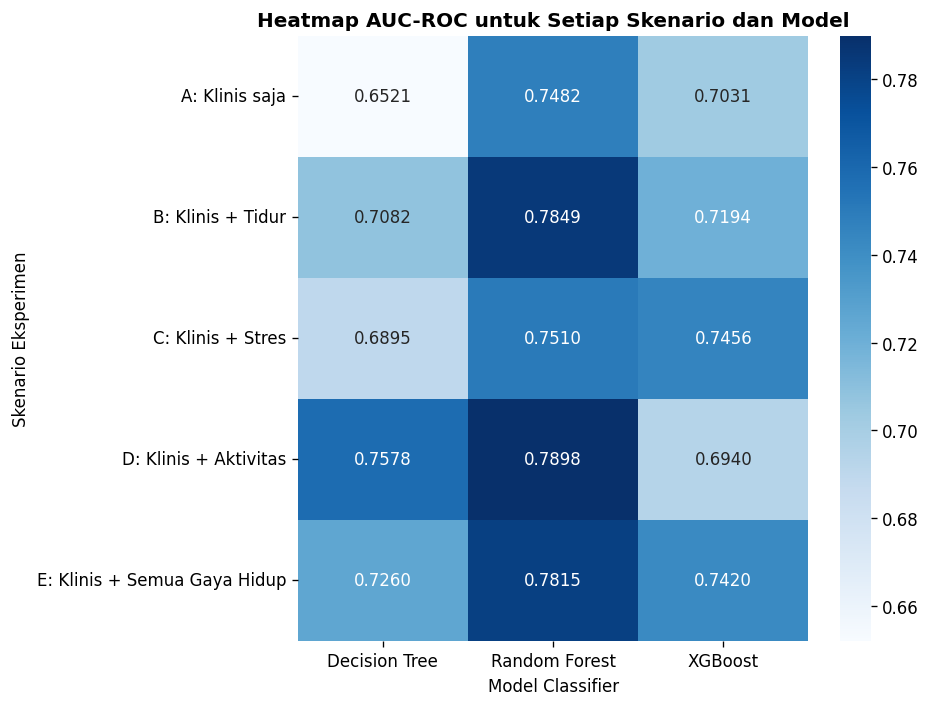

Heatmap tersimpan sebagai heatmap_auc.png


In [13]:
# --- HEATMAP: AUC-ROC SEMUA KOMBINASI --------------------
plt.figure(figsize=(8, 6))
pivot_df = results_df.pivot(index='Skenario', columns='Model', values='AUC-ROC')
pivot_df = pivot_df.reindex(list(SCENARIOS.keys()))
sns.heatmap(pivot_df, annot=True, fmt='.4f', cmap='Blues', cbar=True)
plt.title('Heatmap AUC-ROC untuk Setiap Skenario dan Model', fontsize=12, fontweight='bold')
plt.xlabel('Model Classifier', fontsize=10)
plt.ylabel('Skenario Eksperimen', fontsize=10)
plt.tight_layout()
plt.savefig('heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap tersimpan sebagai heatmap_auc.png')

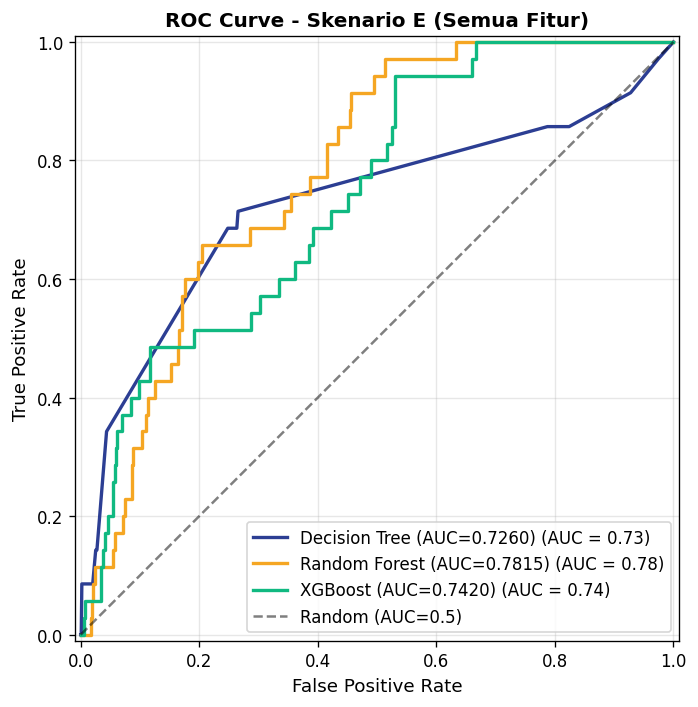

In [14]:
# --- ROC CURVE: MODEL TERBAIK (SKENARIO E) ---------------
fig, ax = plt.subplots(figsize=(7, 6))

for mname, color in zip(model_names, COLORS[:3]):
    if mname in scenario_E_trained_models:
        model_data = scenario_E_trained_models[mname]
        model_instance = model_data['model']
        scaler_instance = model_data['scaler']
        X_test_for_roc = model_data['X_test']
        y_test_for_roc = model_data['y_test']

        X_test_scaled = scaler_instance.transform(X_test_for_roc)

        RocCurveDisplay.from_estimator(
            model_instance,
            X_test_scaled,
            y_test_for_roc,
            name=f'{mname} (AUC={model_data["metrics"]["AUC-ROC"]:.4f})',
            ax=ax,
            color=color,
            linewidth=2
        )
    else:
        print(f"Warning: Model '{mname}' for Scenario E not found in scenario_E_trained_models.")

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)', alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve - Skenario E (Semua Fitur)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# --- PENINGKATAN AUC vs BASELINE (TABEL DELTA) ------------
print('=== PENINGKATAN AUC-ROC DIBANDINGKAN BASELINE (Skenario A) ===\n')
for mname in model_names:
    sub = results_df[results_df['Model'] == mname].set_index('Skenario')
    baseline_auc = sub.loc['A: Klinis saja', 'AUC-ROC']
    print(f'Model: {mname}')
    for scen in list(SCENARIOS.keys())[1:]:
        delta = sub.loc[scen, 'AUC-ROC'] - baseline_auc
        arrow = '+' if delta > 0 else '-'
        print(f'  {scen}: {arrow} {delta:+.4f}')
    print()

=== PENINGKATAN AUC-ROC DIBANDINGKAN BASELINE (Skenario A) ===

Model: Decision Tree
  B: Klinis + Tidur: + +0.0561
  C: Klinis + Stres: + +0.0374
  D: Klinis + Aktivitas: + +0.1057
  E: Klinis + Semua Gaya Hidup: + +0.0739

Model: Random Forest
  B: Klinis + Tidur: + +0.0367
  C: Klinis + Stres: + +0.0028
  D: Klinis + Aktivitas: + +0.0416
  E: Klinis + Semua Gaya Hidup: + +0.0333

Model: XGBoost
  B: Klinis + Tidur: + +0.0163
  C: Klinis + Stres: + +0.0425
  D: Klinis + Aktivitas: - -0.0091
  E: Klinis + Semua Gaya Hidup: + +0.0389



##  8. Analisis SHAP - Explainable AI

In [16]:
# --- SHAP VALUES - Random Forest Skenario E ---------------
print('Menghitung SHAP values... (mungkin 1-2 menit)')

best = trained_models['best']
X_te_sc = best['scaler'].transform(best['X_test'])
X_te_sc_df = pd.DataFrame(X_te_sc, columns=best['features'])

# Gunakan subsample agar lebih cepat
sample_idx = np.random.choice(len(X_te_sc_df), min(300, len(X_te_sc_df)), replace=False)
X_sample = X_te_sc_df.iloc[sample_idx]

explainer = shap.TreeExplainer(best['model'])
shap_values = explainer.shap_values(X_sample)

# Untuk binary classification, ambil class 1 (stroke)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print('SHAP values selesai dihitung!')

Menghitung SHAP values... (mungkin 1-2 menit)


SHAP values selesai dihitung!


In [17]:
if len(sv.shape) == 3:
    sv_class1 = sv[:, :, 1]
else:
    sv_class1 = sv

In [18]:
import pandas as pd
import numpy as np

if len(sv.shape) == 3:
    sv_class1 = sv[:, :, 1]
else:
    sv_class1 = sv

imp = pd.DataFrame({
    'feature': best['features'],
    'mean_abs_shap': np.abs(sv_class1).mean(axis=0)
})

imp = imp.sort_values('mean_abs_shap', ascending=False)
display(imp.head(20))

,feature,mean_abs_shap
9,hypertension,0.097612
0,age,0.058880
14,ever_smoked,0.040110
3,education,0.030666
24,stress_fatigue,0.028680
18,sleep_apnea,0.027540
10,diabetes,0.022268
11,heart_failure,0.020646
12,coronary_disease,0.020545
29,moderate_leisure,0.018886


In [19]:
print(imp.head(10))

             feature  mean_abs_shap
9       hypertension       0.097612
0                age       0.058880
14       ever_smoked       0.040110
3          education       0.030666
24    stress_fatigue       0.028680
18       sleep_apnea       0.027540
10          diabetes       0.022268
11     heart_failure       0.020646
12  coronary_disease       0.020545
29  moderate_leisure       0.018886


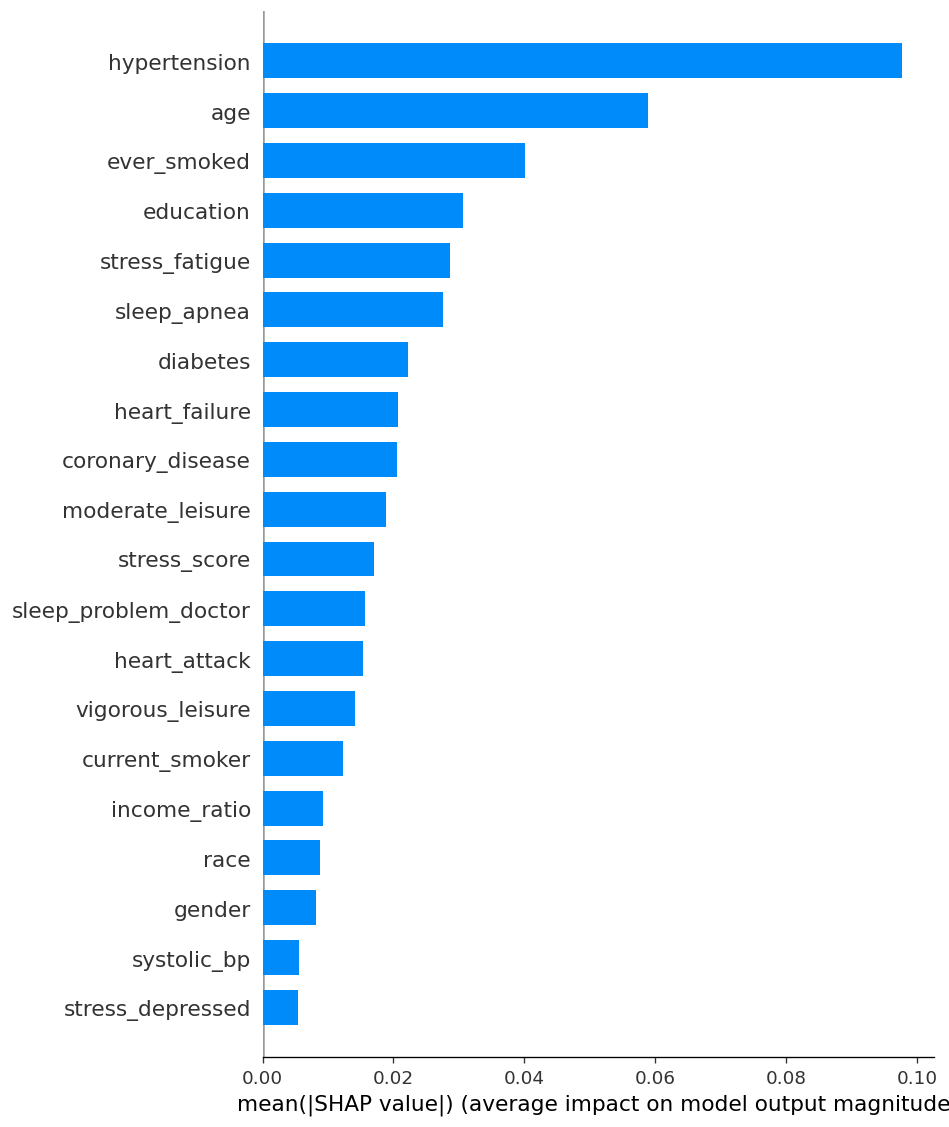

In [20]:
shap.summary_plot(
    sv_class1,
    X_sample,
    feature_names=best['features'],
    plot_type='bar'
)

In [21]:
print(type(sv))

<class 'numpy.ndarray'>


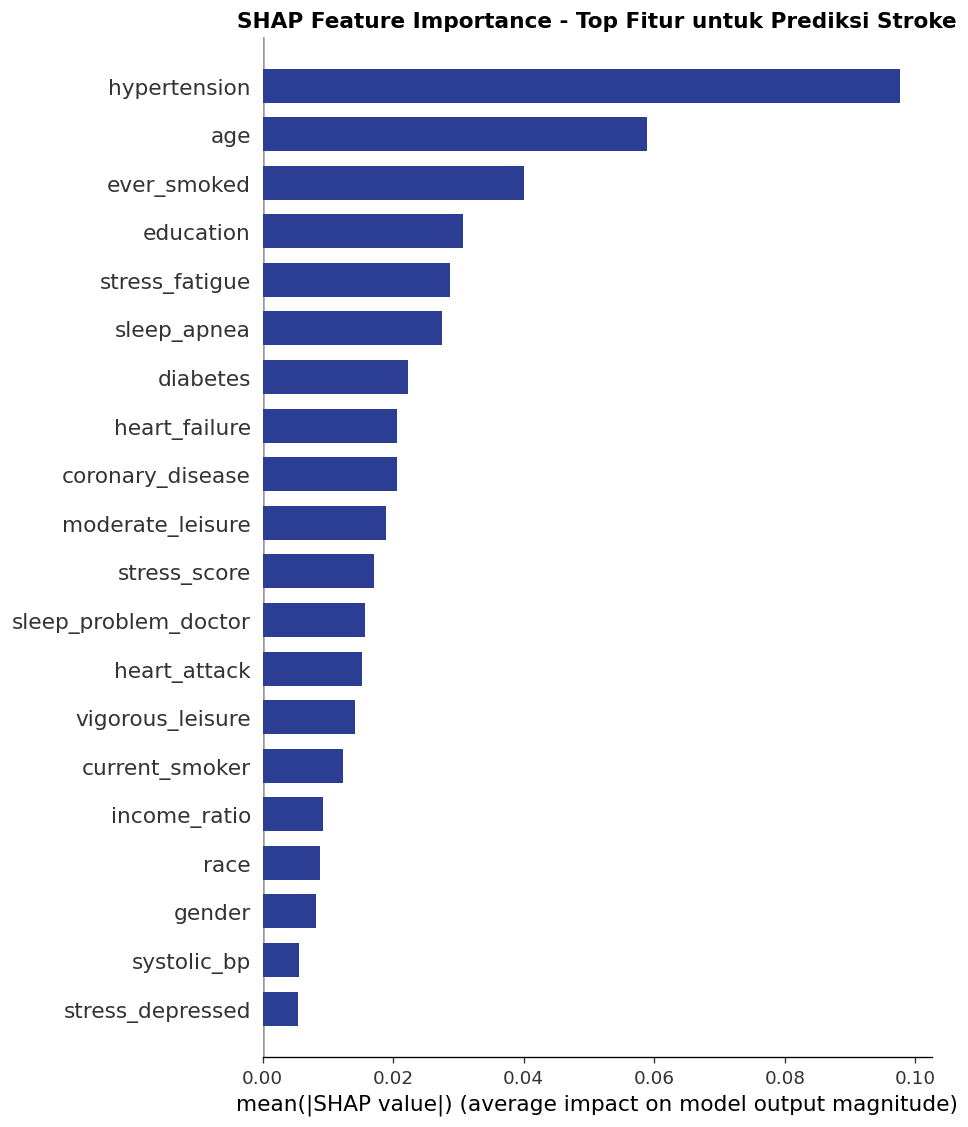

SHAP bar chart tersimpan


In [22]:
# --- SHAP SUMMARY PLOT (Global) ---------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_class1, X_sample,
                  feature_names=best['features'],
                  plot_type='bar',
                  show=False,
                  color=COLORS[0])
plt.title('SHAP Feature Importance - Top Fitur untuk Prediksi Stroke',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP bar chart tersimpan')

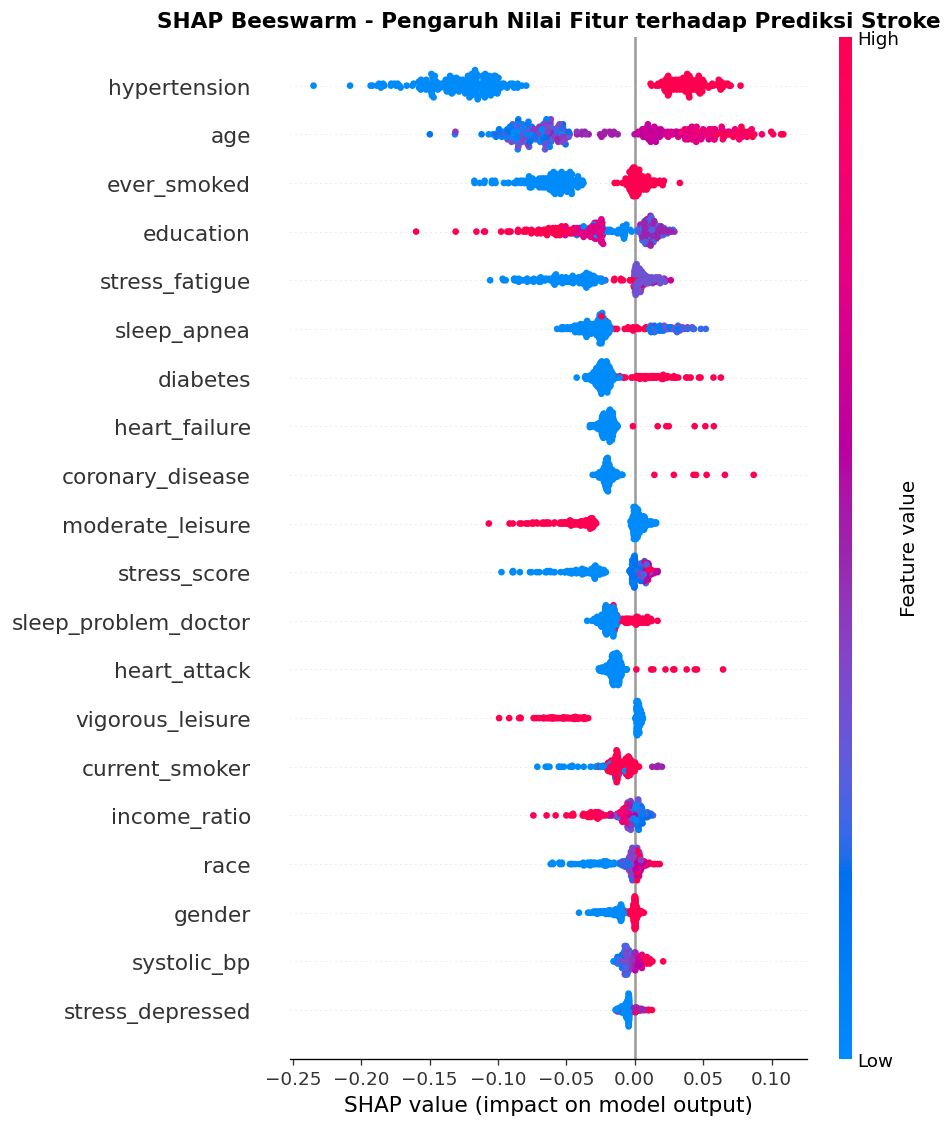

In [23]:
# --- SHAP BEESWARM PLOT (Distribusi nilai) ----------------
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_class1, X_sample,
                  feature_names=best['features'],
                  show=False)
plt.title('SHAP Beeswarm - Pengaruh Nilai Fitur terhadap Prediksi Stroke',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

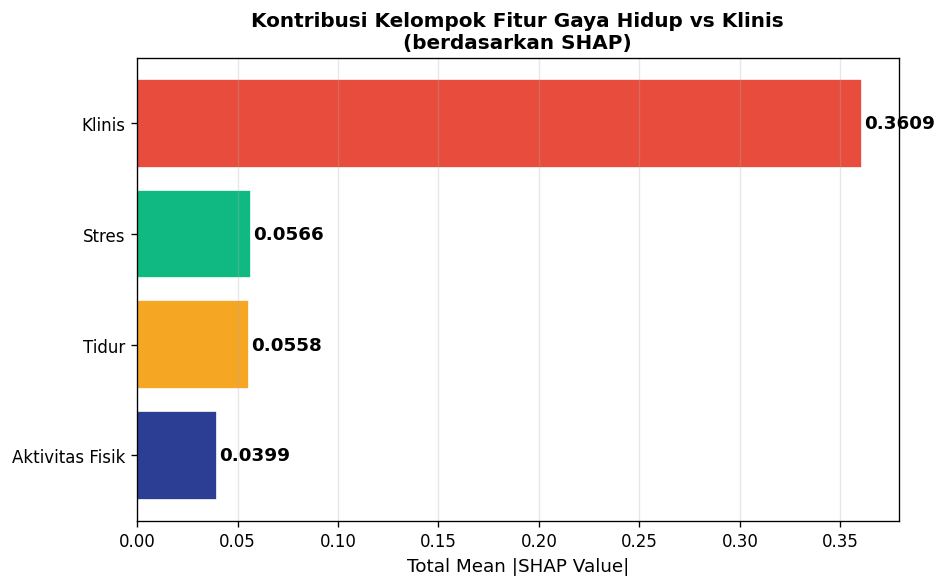


=== RANKING KELOMPOK FITUR (berdasarkan SHAP) ===
1. Klinis: 0.3609
2. Stres: 0.0566
3. Tidur: 0.0558
4. Aktivitas Fisik: 0.0399


In [24]:
# --- SHAP per KELOMPOK FITUR ------------------------------
available_feats = best['features']

shap_df = pd.DataFrame(np.abs(sv_class1), columns=available_feats)
mean_shap = shap_df.mean()

groups = {
    'Klinis': [c for c in CLINICAL if c in available_feats],
    'Tidur':  [c for c in SLEEP    if c in available_feats],
    'Stres':  [c for c in STRESS   if c in available_feats],
    'Aktivitas Fisik': [c for c in PHYSICAL if c in available_feats],
}

group_shap = {}
for grp, cols in groups.items():
    if cols:
        group_shap[grp] = mean_shap[cols].sum()

fig, ax = plt.subplots(figsize=(8, 5))
gs = pd.Series(group_shap).sort_values(ascending=True)
bars = ax.barh(gs.index, gs.values,
               color=[COLORS[0], COLORS[1], COLORS[2], COLORS[3]][:len(gs)],
               edgecolor='white')

for bar, val in zip(bars, gs.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Total Mean |SHAP Value|', fontsize=11)
ax.set_title('Kontribusi Kelompok Fitur Gaya Hidup vs Klinis\n(berdasarkan SHAP)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_groups.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== RANKING KELOMPOK FITUR (berdasarkan SHAP) ===')
for rank, (grp, val) in enumerate(gs.sort_values(ascending=False).items(), 1):
    print(f'{rank}. {grp}: {val:.4f}')

In [25]:
# --- DOWNLOAD SEMUA HASIL --------------------------------
# Simpan tabel hasil ke CSV
results_df.to_csv('hasil_eksperimen.csv', index=False)
print('hasil_eksperimen.csv tersimpan')

# Download dari Colab
try:
    from google.colab import files
    files.download('hasil_eksperimen.csv')
    files.download('auc_comparison.png')
    files.download('heatmap_auc.png')
    files.download('shap_summary_bar.png')
    files.download('shap_beeswarm.png')
    files.download('shap_groups.png')
    print('Semua file berhasil didownload!')
except:
    print('(Tidak di Colab - file tersimpan di direktori lokal)')

hasil_eksperimen.csv tersimpan
(Tidak di Colab - file tersimpan di direktori lokal)


---
##  Ringkasan Hasil

Setelah menjalankan semua cell di atas, kalian akan mendapatkan:

| Output | Isi |
|--------|-----|
| `hasil_eksperimen.csv` | Tabel lengkap Accuracy/Precision/Recall/F1/AUC-ROC semua skenario & model |
| `auc_comparison.png` | Bar chart perbandingan AUC per skenario |
| `heatmap_auc.png` | Heatmap AUC semua kombinasi |
| `shap_summary_bar.png` | Fitur terpenting secara global |
| `shap_beeswarm.png` | Distribusi pengaruh tiap fitur |
| `shap_groups.png` | **Jawaban pertanyaan utama** - kelompok mana yang paling berpengaruh |

### Cara menjawab rumusan masalah dari hasil:
- **RQ1**: Lihat tabel hasil, bandingkan Accuracy & AUC-ROC ketiga model pada Skenario A
- **RQ2-RQ4**: Lihat delta AUC Skenario B, C, D vs Skenario A
- **RQ5**: Lihat grafik `shap_groups.png` → kelompok dengan SHAP tertinggi = paling berpengaruh
